In [12]:
import sys
import time
import serial
import  glob
from matplotlib import pyplot as plt
import numpy as np
from helpers import findDevice, get_par_MP, plot_data_and_fit, set_MP_name, get_MP_name, r_squared


In [5]:
# Initialize ports for MiniPAR


PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)

Received message: MiniPAR,1.1, port: /dev/ttyACM0
Found device at: /dev/ttyACM0, answer: MiniPAR,1.1



In [8]:
print("Raw values:", get_par_MP(PORT_MINIPAR, raw=True))
time.sleep(0.05) # otherwise might overcome serial 
print("Calibrated values:", get_par_MP(PORT_MINIPAR, raw=False))


Raw values: 0.12
Calibrated values: 0.12


In [ ]:
print("Starting calibration...")
print("Put the miniPAR close to a reference PAR sensor")
print("Going to measure at 2 different light intensities")
# regression curve
reference_data = []
sensor_data = []

print("Measure in the light:")
ref_val = float(input("Enter the reference PAR value from the reference sensor: "))
sens_val = get_par_MP(PORT_MINIPAR, raw=True)
reference_data.append(ref_val)
sensor_data.append(sens_val)
time.sleep(1.0)

print("Measure in the dark:")
ref_val = float(input("Enter the reference PAR value from the reference sensor: "))
sens_val = get_par_MP(PORT_MINIPAR, raw=True)
reference_data.append(ref_val)
sensor_data.append(sens_val)
    

Starting calibration...
Put the miniPAR close to a reference PAR sensor
Going to measure at 2 different light intensities
Measure in the light:
Measure in the dark:


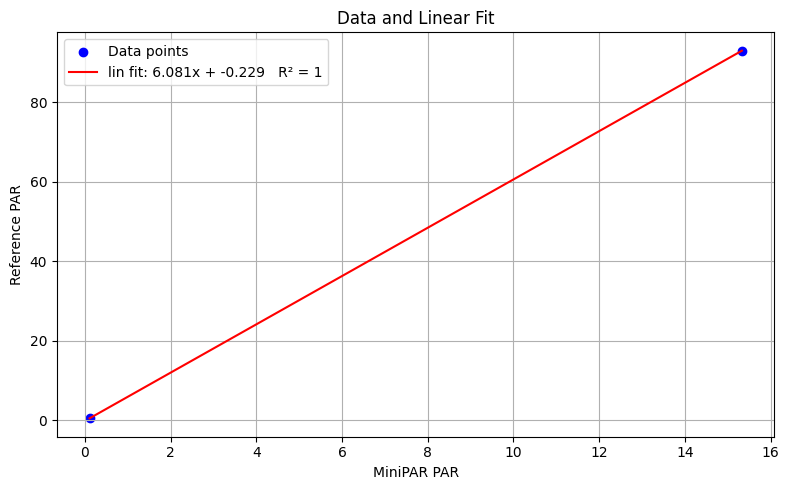

In [13]:
# Perform linear regression and plot results

y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, xlabel="MiniPAR PAR", ylabel="Reference PAR")


 


In [14]:
# upload the calibration coefficient to the miniPAR
slope = coeffs[0]
offset = coeffs[1]
with serial.Serial(PORT_MINIPAR) as ser:
    ser.write(f"cal_par_slope,{slope:.6g}\n".encode())
    print(ser.readline())
    time.sleep(0.3)
    ser.write(f"cal_par_intercept,{offset:.6g}\n".encode())
    print(ser.readline())

b'6.08\r\n'
b'-0.23\r\n'


In [ ]:
print("Raw values:", get_par_MP(PORT_MINIPAR, raw=True))
time.sleep(0.5) # otherwise might overcome serial 
print("Calibrated values:", get_par_MP(PORT_MINIPAR, raw=False))


NameError: name 'get_par' is not defined

In [ ]:


set_MP_name(PORT_MINIPAR, name="miniPAR")
time.sleep(0.5)
print(get_MP_name(PORT_MINIPAR))


miniPAR
